# 08 — SHAP : Explicabilité de XGBoost pour analystes SOC

## 🎯 Objectif

Appliquer **SHAP** (Shapley Additive exPlanations) à notre meilleur modèle (XGBoost optimisé) pour répondre à la question :

> **Comment expliquer chaque détection d'intrusion à un analyste SOC ?**

C'est **le cœur original** de ton projet. Ce notebook produit les figures et analyses qui constitueront la section Phase D de ton mémoire.

## 📋 Plan

1. Setup et chargement du modèle XGBoost
2. Sampling stratifié du test set (SHAP est coûteux sur 377k échantillons)
3. Création du SHAP TreeExplainer
4. Calcul des SHAP values
5. **Explications GLOBALES** (vue d'ensemble du modèle)
6. **Explications LOCALES** sur 4 cas SOC réels :
   - Cas A : vrai DDoS détecté correctement
   - Cas B : vrai Bot détecté correctement
   - Cas C : faux positif (BENIGN classé attaque)
   - Cas D : faux négatif (attaque manquée)
7. Sauvegarde des SHAP values pour notebook 09 (LIME)

## ⏱️ Temps estimé

**~10-15 minutes**. TreeSHAP est très rapide sur les modèles d'arbres.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import shap
from pathlib import Path
from time import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

DATA_PROCESSED = Path('../data/processed')
RESULTS_FIGURES = Path('../results/figures')
RESULTS_METRICS = Path('../results/metrics')
RESULTS_MODELS = Path('../results/models')
RESULTS_XAI = Path('../results/xai')
RESULTS_XAI.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

print(f'✅ SHAP version : {shap.__version__}')

✅ SHAP version : 0.52.0


## 2. Chargement du modèle XGBoost et des données

In [2]:
# Modèle XGBoost
xgb_model = joblib.load(RESULTS_MODELS / 'xgb_optimized.joblib')
print('✅ XGBoost chargé')

# Données
df = pd.read_parquet(DATA_PROCESSED / 'cic-ids-2017_clean.parquet')
with open(DATA_PROCESSED / 'label_mapping.json') as f:
    label_mapping = json.load(f)
label_mapping = {int(k): v for k, v in label_mapping.items()}
class_names = [label_mapping[i] for i in sorted(label_mapping.keys())]

y = df['Label_encoded'].values
feature_cols = [c for c in df.columns if c not in ['Label', 'Label_encoded']]
X = df[feature_cols].values.astype(np.float32)

# Même split que les autres notebooks
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)

print(f'📊 Test set : {X_test.shape[0]:,} échantillons × {X_test.shape[1]} features')
print(f'🏷️  Classes : {class_names}')

✅ XGBoost chargé
📊 Test set : 377,682 échantillons × 77 features
🏷️  Classes : ['BENIGN', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'PortScan', 'Web Attack']


## 3. Sampling stratifié du test set

### 📚 Pourquoi un sample ?

TreeSHAP est rapide, mais calculer les SHAP values sur 377 000 échantillons × 78 features × 7 classes prendrait beaucoup de mémoire et de temps. On prend un **sous-ensemble représentatif** :

- ~5000 échantillons au total
- **Stratifié** : on garde les proportions de classes
- **Suffisant** pour des explications globales fiables et pour démontrer la méthode

Pour des explications locales, on travaillera sur des cas individuels.

In [3]:
# Sample stratifié de ~5000 lignes
SAMPLE_SIZE = 5000

indices = []
for cls in np.unique(y_test):
    cls_indices = np.where(y_test == cls)[0]
    # Au moins 50 par classe, ou tout si moins
    n_take = min(len(cls_indices), max(50, int(SAMPLE_SIZE * len(cls_indices) / len(y_test))))
    sampled = np.random.choice(cls_indices, size=n_take, replace=False)
    indices.extend(sampled)

indices = np.array(indices)
X_sample = X_test[indices]
y_sample = y_test[indices]

print(f'📊 Échantillon SHAP : {len(X_sample):,} lignes')
print(f'\nDistribution du sample :')
for cls in np.unique(y_sample):
    n = (y_sample == cls).sum()
    print(f'  {label_mapping[cls]:15s} : {n:>5,}')

📊 Échantillon SHAP : 5,123 lignes

Distribution du sample :
  BENIGN          : 4,155
  Bot             :    50
  Brute Force     :    50
  DDoS            :   254
  DoS             :   384
  PortScan        :   180
  Web Attack      :    50


## 4. Création du TreeExplainer SHAP

### 📚 Pourquoi TreeExplainer ?

SHAP propose plusieurs "explainers" selon le modèle :
- **TreeExplainer** : pour les modèles d'arbres (XGBoost, RandomForest, LightGBM) → **exact et rapide**
- **DeepExplainer** : pour les modèles deep (réseaux de neurones) → approximatif
- **KernelExplainer** : générique, pour n'importe quel modèle → lent

On utilise TreeExplainer car XGBoost est un modèle d'arbres → calcul exact des Shapley values en temps polynomial.

In [4]:
explainer = shap.TreeExplainer(xgb_model)
print('✅ TreeExplainer créé')
print(f'   Type : {type(explainer).__name__}')
print(f'   Base value (expected_value) : {explainer.expected_value if not isinstance(explainer.expected_value, np.ndarray) else explainer.expected_value.tolist()}')

✅ TreeExplainer créé
   Type : TreeExplainer
   Base value (expected_value) : [-0.008491268009209301, 0.024813214749884075, -0.022602954857574794, -0.03915235983913455, -0.009518989917525216, 0.007584585951234669, -0.09616022553836912]


## 5. Calcul des SHAP values

Pour un modèle multi-classe XGBoost, SHAP retourne soit :
- Une **liste** de N arrays (un par classe), chaque array de shape `(n_samples, n_features)`
- Soit un **array 3D** `(n_samples, n_features, n_classes)` selon la version

On gère les deux cas.

In [5]:
print('🧮 Calcul des SHAP values en cours...')
t0 = time()
shap_values_raw = explainer.shap_values(X_sample)
elapsed = time() - t0
print(f'✅ Calcul terminé en {elapsed:.1f}s')

# Normalisation du format : on veut un array 3D (samples, features, classes)
if isinstance(shap_values_raw, list):
    # Ancien format SHAP : liste de N arrays 2D
    shap_values = np.stack(shap_values_raw, axis=-1)
    print(f'Format détecté : liste de {len(shap_values_raw)} arrays 2D')
else:
    # Nouveau format SHAP : array 3D
    shap_values = shap_values_raw
    print('Format détecté : array 3D')

print(f'\nShape des SHAP values : {shap_values.shape}')
print(f'  → {shap_values.shape[0]:,} samples')
print(f'  → {shap_values.shape[1]} features')
print(f'  → {shap_values.shape[2]} classes')

🧮 Calcul des SHAP values en cours...
✅ Calcul terminé en 1.1s
Format détecté : array 3D

Shape des SHAP values : (5123, 77, 7)
  → 5,123 samples
  → 77 features
  → 7 classes


## 6. Explications GLOBALES : vue d'ensemble du modèle

### 6.1 Importance moyenne par feature, toutes classes confondues

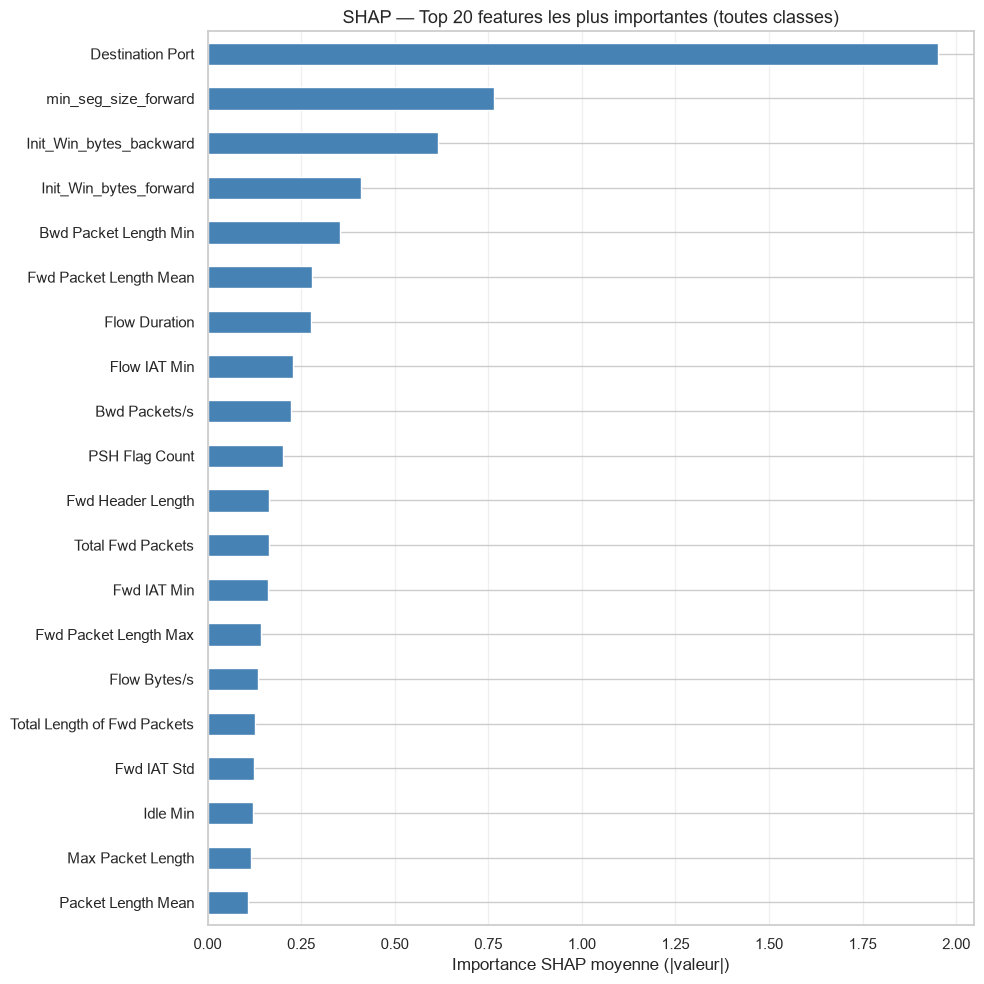


Top 10 features SHAP :
  Destination Port                         : 1.9501
  min_seg_size_forward                     : 0.7651
  Init_Win_bytes_backward                  : 0.6157
  Init_Win_bytes_forward                   : 0.4098
  Bwd Packet Length Min                    : 0.3542
  Fwd Packet Length Mean                   : 0.2803
  Flow Duration                            : 0.2774
  Flow IAT Min                             : 0.2285
  Bwd Packets/s                            : 0.2231
  PSH Flag Count                           : 0.2015


In [6]:
# Importance moyenne absolue = moyenne sur classes ET samples des |SHAP values|
mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))   # moyenne sur samples et classes
feature_importance_shap = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
feature_importance_shap.tail(20).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Importance SHAP moyenne (|valeur|)')
ax.set_title('SHAP — Top 20 features les plus importantes (toutes classes)', fontsize=13)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '08_shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features SHAP :')
for feat, imp in feature_importance_shap.tail(10).iloc[::-1].items():
    print(f'  {feat:40s} : {imp:.4f}')

### 6.2 Importance des features PAR CLASSE

Question cyber : *"Quelles features sont utilisées pour détecter chaque type d'attaque ?"*

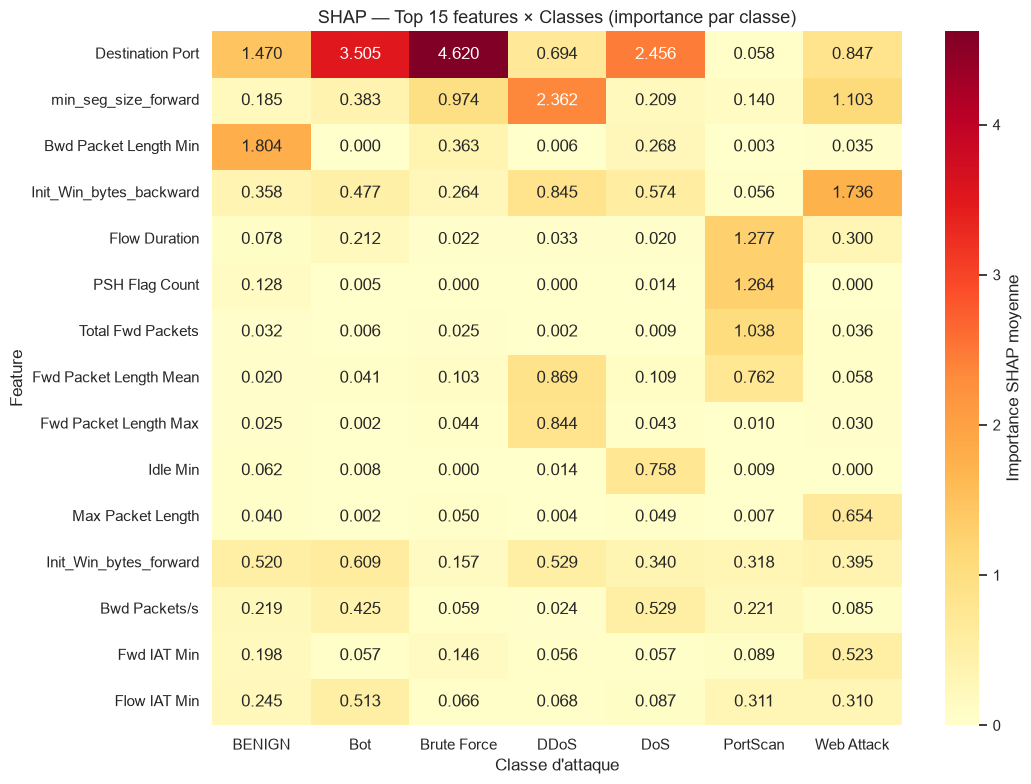

In [7]:
# Importance par classe : moyenne absolue sur les samples
importance_per_class = pd.DataFrame(
    np.abs(shap_values).mean(axis=0),       # shape (features, classes)
    index=feature_cols,
    columns=class_names,
)

# Heatmap des top 15 features × 7 classes
top_features = importance_per_class.max(axis=1).sort_values(ascending=False).head(15).index
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    importance_per_class.loc[top_features],
    cmap='YlOrRd', annot=True, fmt='.3f',
    cbar_kws={'label': 'Importance SHAP moyenne'},
    ax=ax,
)
ax.set_title('SHAP — Top 15 features × Classes (importance par classe)', fontsize=13)
ax.set_xlabel('Classe d\'attaque')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '08_shap_importance_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Summary plot (beeswarm) pour la classe DDoS

Vue détaillée : pour chaque sample, où se situe sa SHAP value pour la classe DDoS ?

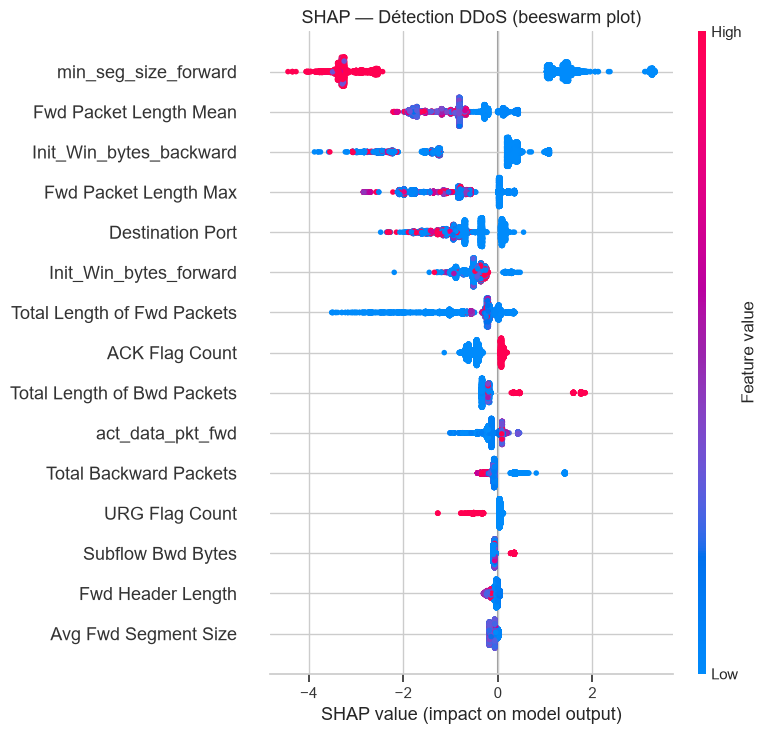

In [8]:
# Index de la classe DDoS
ddos_idx = class_names.index('DDoS')

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values[:, :, ddos_idx],
    X_sample,
    feature_names=feature_cols,
    max_display=15,
    show=False,
)
plt.title(f'SHAP — Détection DDoS (beeswarm plot)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '08_shap_beeswarm_DDoS.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Summary plots pour les autres classes d'attaque

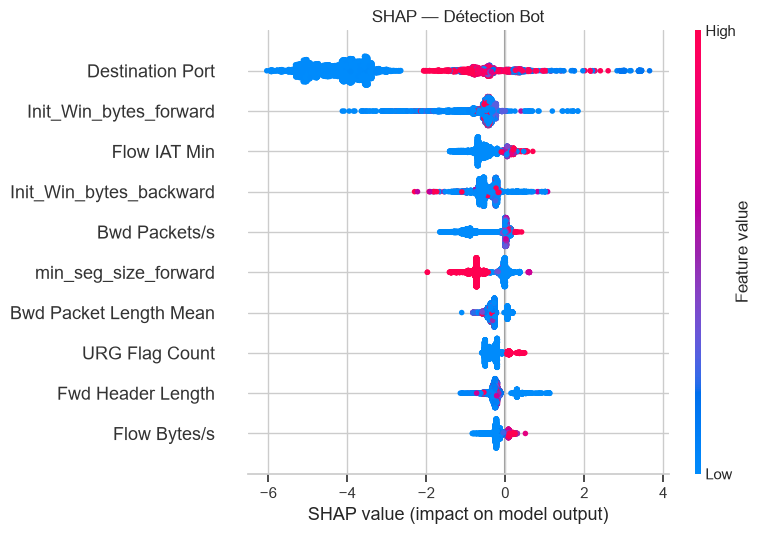

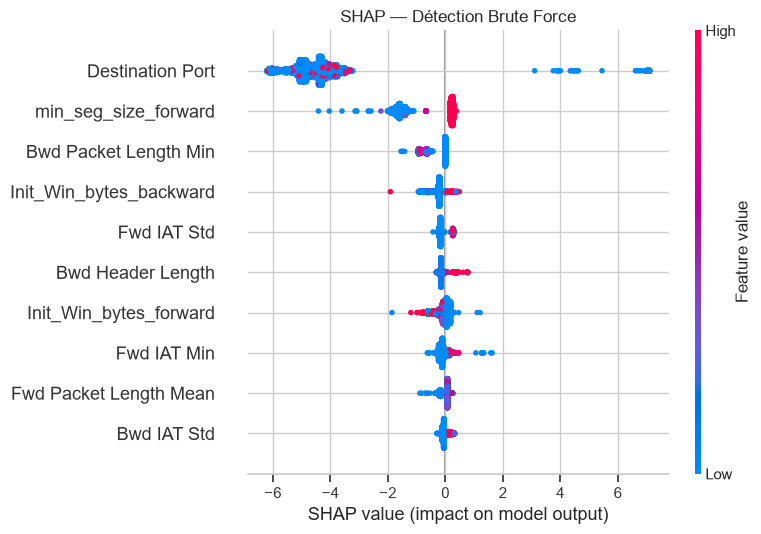

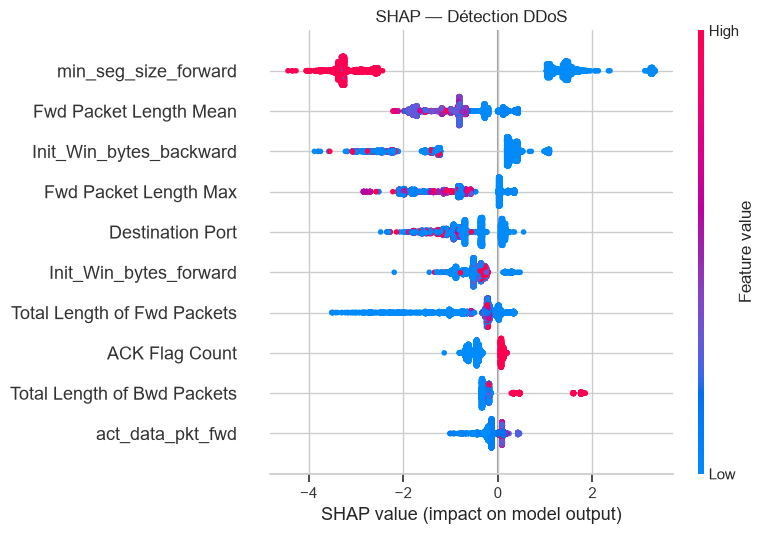

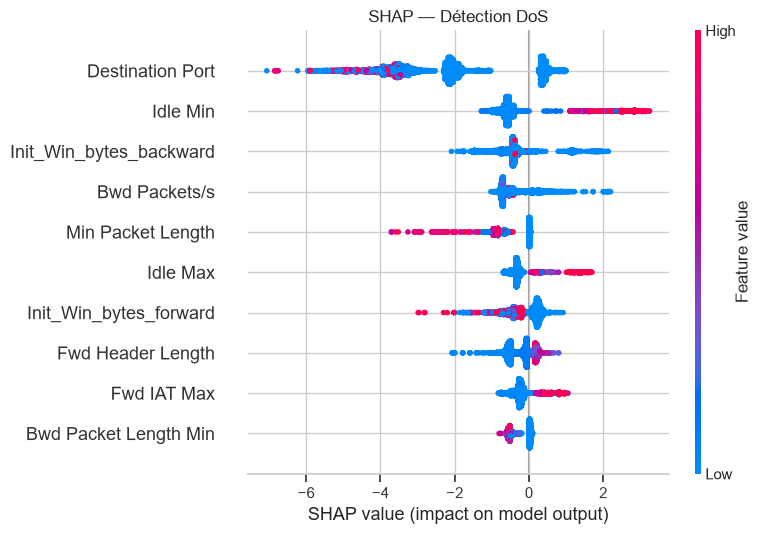

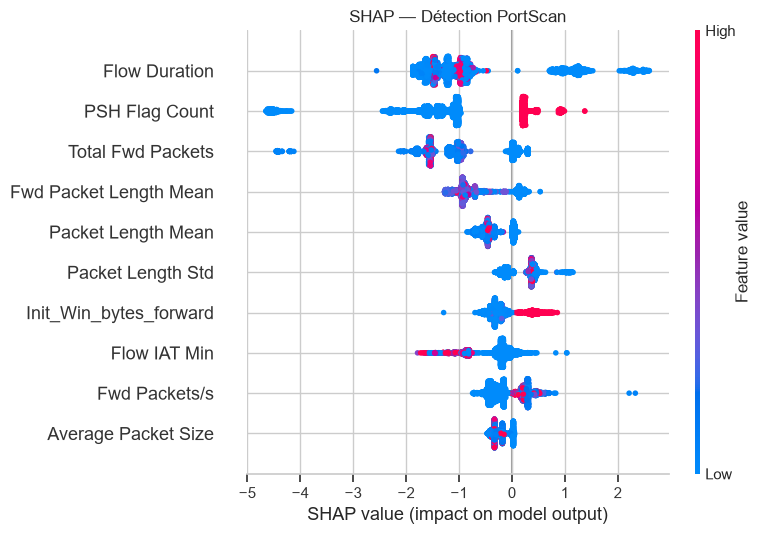

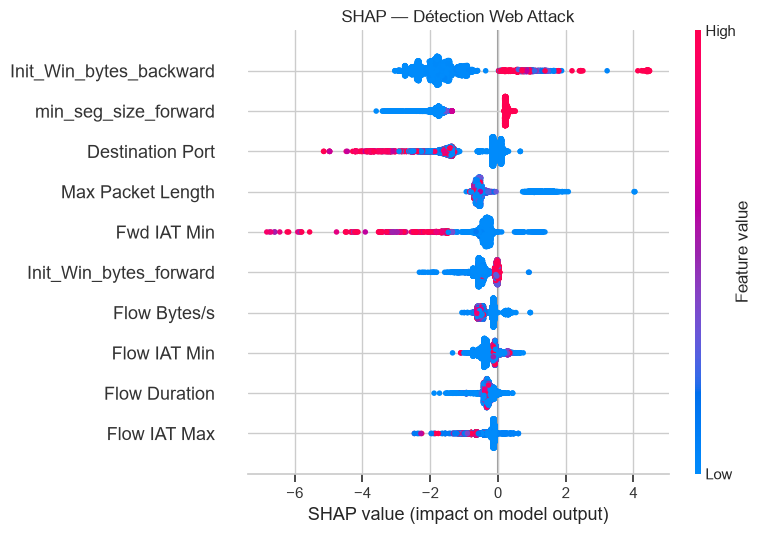

In [9]:
# Beeswarm pour chaque classe d'attaque (sauf BENIGN)
attack_classes = [c for c in class_names if c != 'BENIGN']

for cls in attack_classes:
    cls_idx = class_names.index(cls)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values[:, :, cls_idx],
        X_sample,
        feature_names=feature_cols,
        max_display=10,
        show=False,
    )
    plt.title(f'SHAP — Détection {cls}', fontsize=12)
    plt.tight_layout()
    safe_name = cls.replace(' ', '_')
    plt.savefig(RESULTS_FIGURES / f'08_shap_beeswarm_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Explications LOCALES : 4 cas SOC réels

C'est ici que ton projet prend tout son sens opérationnel. **Pour chaque cas, on raconte l'histoire que SHAP permet de comprendre.**

In [10]:
# Prédictions du modèle sur notre sample
y_sample_pred = xgb_model.predict(X_sample)

# Sélection des 4 cas
def find_case(true_class, pred_class, n=1):
    """Trouve les indices d'échantillons avec une vraie classe et une classe prédite données."""
    true_idx = class_names.index(true_class)
    pred_idx = class_names.index(pred_class)
    mask = (y_sample == true_idx) & (y_sample_pred == pred_idx)
    return np.where(mask)[0][:n]

# Cas A : Vrai DDoS détecté correctement
case_a = find_case('DDoS', 'DDoS', n=1)
# Cas B : Vrai Bot détecté correctement
case_b = find_case('Bot', 'Bot', n=1)
# Cas C : BENIGN mal classé en Bot (faux positif)
case_c = find_case('BENIGN', 'Bot', n=1)
# Cas D : DoS mal classé en BENIGN (faux négatif — attaque ratée)
case_d = find_case('DoS', 'BENIGN', n=1)
if len(case_d) == 0:
    case_d = find_case('Web Attack', 'BENIGN', n=1)   # fallback

print('📋 Cas SOC sélectionnés :')
print(f'  Cas A (vrai DDoS détecté)             : index {case_a[0] if len(case_a) else "N/A"}')
print(f'  Cas B (vrai Bot détecté)              : index {case_b[0] if len(case_b) else "N/A"}')
print(f'  Cas C (faux positif BENIGN→Bot)       : index {case_c[0] if len(case_c) else "N/A"}')
print(f'  Cas D (faux négatif attaque→BENIGN)   : index {case_d[0] if len(case_d) else "N/A"}')

📋 Cas SOC sélectionnés :
  Cas A (vrai DDoS détecté)             : index 4255
  Cas B (vrai Bot détecté)              : index 4155
  Cas C (faux positif BENIGN→Bot)       : index 1398
  Cas D (faux négatif attaque→BENIGN)   : index N/A



  CAS : Cas_A_True_DDoS_Detected
  Vraie classe     : DDoS
  Classe prédite   : DDoS

📊 Top 10 features ayant contribué à la prédiction "DDoS" :
                    Feature  Valeur  Contribution SHAP
       min_seg_size_forward    20.0           3.319405
Total Length of Bwd Packets 11607.0           1.601635
    Init_Win_bytes_backward   229.0           1.075467
     Fwd Packet Length Mean     7.0           0.383248
          Subflow Bwd Bytes 11607.0           0.325344
      Fwd Packet Length Max    20.0           0.270972
     Bwd Packet Length Mean  1934.5           0.253168
          Fwd Header Length   172.0          -0.200829
Total Length of Fwd Packets    56.0           0.191882
           act_data_pkt_fwd     6.0           0.184701


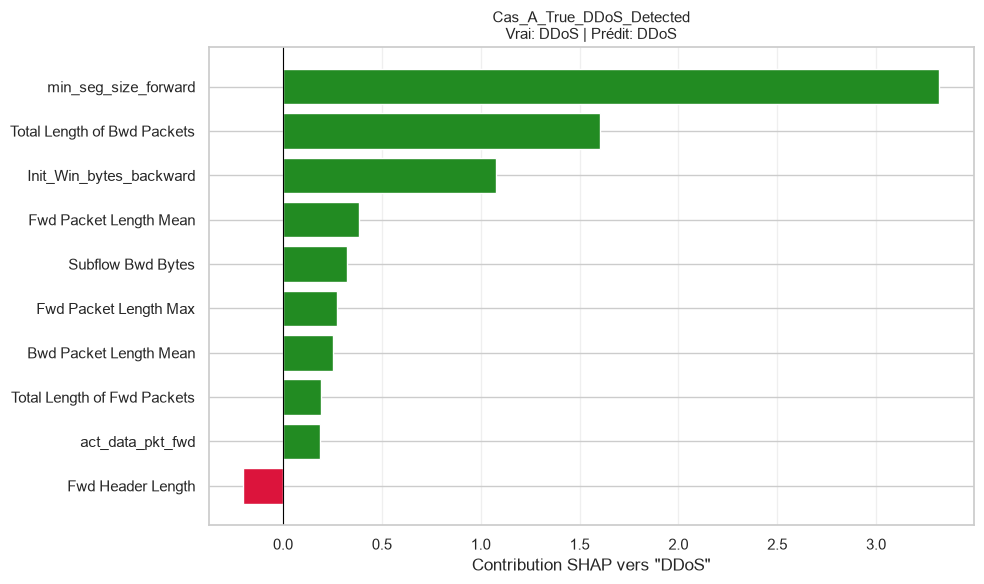

In [11]:
def explain_local(case_idx, case_label):
    """Génère une explication SHAP locale pour un cas donné."""
    if case_idx is None or (hasattr(case_idx, '__len__') and len(case_idx) == 0):
        print(f'⚠️  Pas d\'exemple trouvé pour {case_label}')
        return
    if hasattr(case_idx, '__len__'):
        case_idx = case_idx[0]
    
    true_cls = label_mapping[y_sample[case_idx]]
    pred_cls = label_mapping[y_sample_pred[case_idx]]
    
    print(f'\n{"="*75}')
    print(f'  CAS : {case_label}')
    print(f'  Vraie classe     : {true_cls}')
    print(f'  Classe prédite   : {pred_cls}')
    print(f'{"="*75}')
    
    # SHAP values pour la classe prédite
    pred_class_idx = class_names.index(pred_cls)
    shap_vals_local = shap_values[case_idx, :, pred_class_idx]
    
    # Top 10 features qui ont contribué à la prédiction (positivement ou négativement)
    contributions = pd.DataFrame({
        'Feature': feature_cols,
        'Valeur': X_sample[case_idx],
        'Contribution SHAP': shap_vals_local,
    })
    contributions['Abs'] = contributions['Contribution SHAP'].abs()
    top_contribs = contributions.nlargest(10, 'Abs').drop('Abs', axis=1)
    
    print(f'\n📊 Top 10 features ayant contribué à la prédiction "{pred_cls}" :')
    print(top_contribs.to_string(index=False))
    
    # Waterfall plot
    fig, ax = plt.subplots(figsize=(10, 6))
    top_contribs_sorted = top_contribs.sort_values('Contribution SHAP')
    colors = ['crimson' if v < 0 else 'forestgreen' for v in top_contribs_sorted['Contribution SHAP']]
    ax.barh(top_contribs_sorted['Feature'], top_contribs_sorted['Contribution SHAP'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel(f'Contribution SHAP vers "{pred_cls}"')
    ax.set_title(f'{case_label}\nVrai: {true_cls} | Prédit: {pred_cls}', fontsize=11)
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    safe_label = case_label.replace(' ', '_').replace('(', '').replace(')', '').replace('→', 'to')
    plt.savefig(RESULTS_FIGURES / f'08_shap_local_{safe_label}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return top_contribs

# Cas A
contribs_a = explain_local(case_a, 'Cas_A_True_DDoS_Detected')


  CAS : Cas_B_True_Bot_Detected
  Vraie classe     : Bot
  Classe prédite   : Bot

📊 Top 10 features ayant contribué à la prédiction "Bot" :
                Feature        Valeur  Contribution SHAP
       Destination Port   8080.000000           2.945516
   min_seg_size_forward     28.000000           0.607298
Init_Win_bytes_backward      0.000000           0.517209
            Bwd IAT Max 503433.000000           0.457454
            Bwd IAT Std   1385.929321          -0.453757
           Flow IAT Max 502652.000000          -0.433895
           Flow IAT Min    478.000000           0.304625
            Fwd IAT Min 501448.000000           0.297341
          Bwd Packets/s      2.983934          -0.271327
    Average Packet Size      3.000000          -0.265694


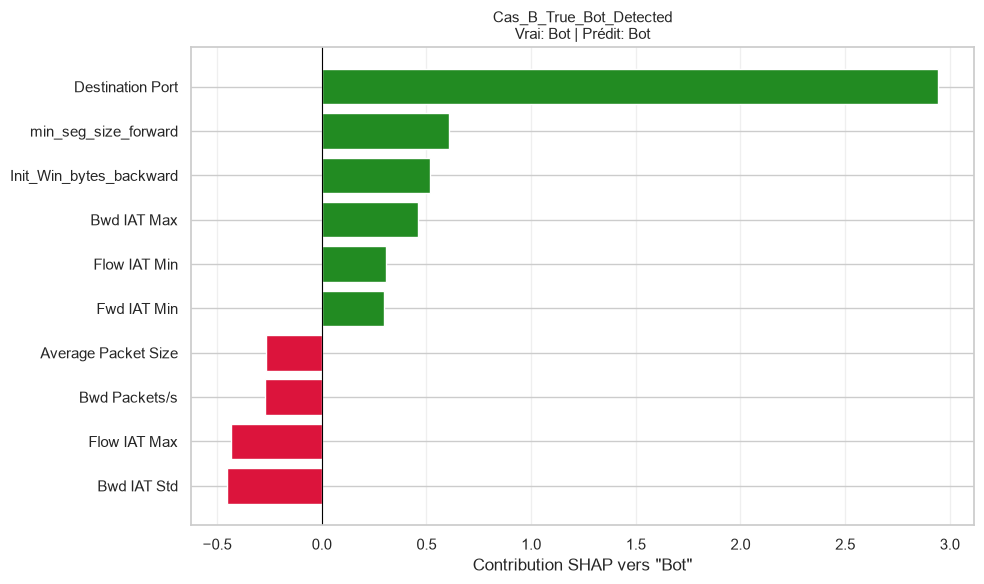

In [12]:
# Cas B
contribs_b = explain_local(case_b, 'Cas_B_True_Bot_Detected')


  CAS : Cas_C_False_Positive_BENIGN_to_Bot
  Vraie classe     : BENIGN
  Classe prédite   : Bot

📊 Top 10 features ayant contribué à la prédiction "Bot" :
                Feature  Valeur  Contribution SHAP
       Destination Port  2823.0           1.753748
      Fwd Header Length    20.0           1.041963
 Init_Win_bytes_forward   254.0          -0.972534
           Flow IAT Min    32.0          -0.543707
Init_Win_bytes_backward   256.0           0.477834
   min_seg_size_forward    20.0           0.336286
  Bwd Packet Length Max     6.0          -0.228892
            Bwd IAT Max     0.0           0.223296
          Bwd IAT Total     0.0          -0.167569
         URG Flag Count     1.0           0.132372


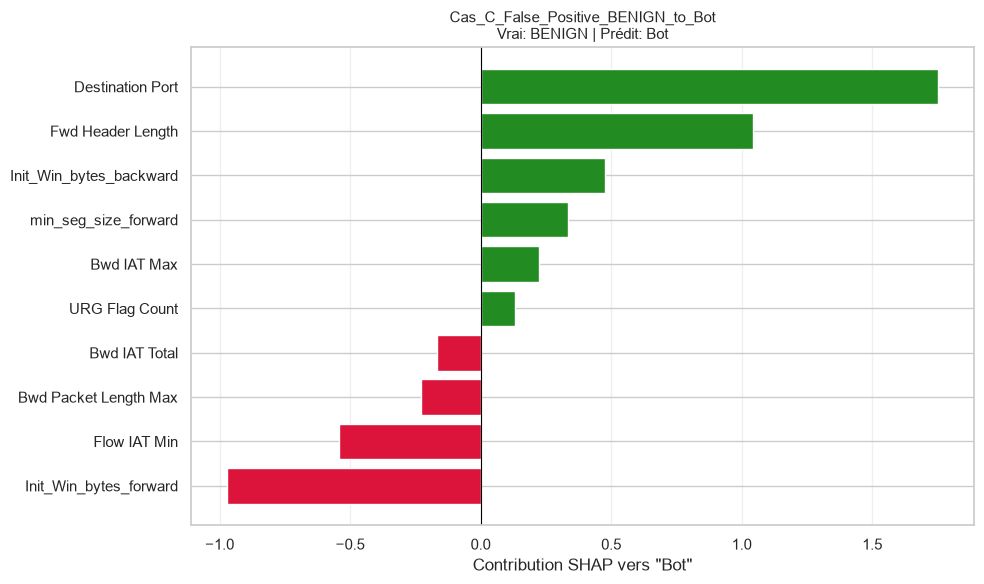

In [13]:
# Cas C
contribs_c = explain_local(case_c, 'Cas_C_False_Positive_BENIGN_to_Bot')

In [14]:
# Cas D
contribs_d = explain_local(case_d, 'Cas_D_False_Negative_Attack_missed')

⚠️  Pas d'exemple trouvé pour Cas_D_False_Negative_Attack_missed


Nombre d'attaques mal classées dans le sample : 1

Confusions trouvées :
  Index  5122 : Vrai=Web Attack      -> Predit=DoS

Cas D choisi : confusion Web Attack -> DoS (index 5122)

  CAS : Cas_D_Misclassification
  Vraie classe     : Web Attack
  Classe prédite   : DoS

📊 Top 10 features ayant contribué à la prédiction "DoS" :
               Feature       Valeur  Contribution SHAP
 Fwd Packet Length Std 2.449490e+02           2.261535
 Bwd Packet Length Std 1.302377e+03           0.982808
              Idle Min 0.000000e+00          -0.749479
         Bwd Packets/s 7.980083e-01          -0.605323
      Destination Port 8.000000e+01           0.571964
              Idle Max 0.000000e+00          -0.465572
           Fwd IAT Max 5.000160e+06          -0.418228
     Fwd Header Length 2.000000e+02           0.253022
Bwd Packet Length Mean 1.037250e+03          -0.238997
         Flow Duration 5.012479e+06          -0.238327


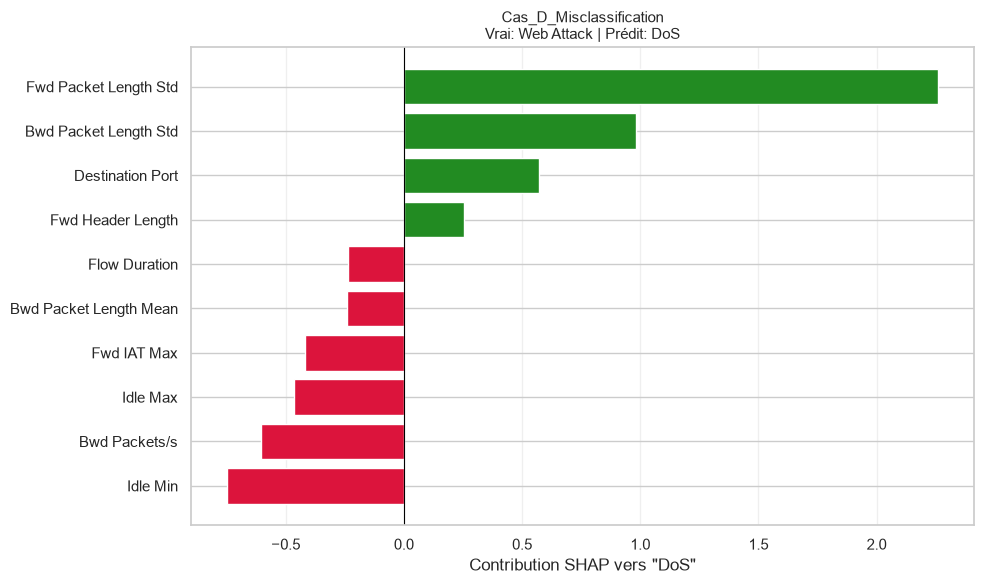

In [16]:
# Recherche élargie : n'importe quelle attaque mal classée
mask_attack = (y_sample != class_names.index('BENIGN'))
mask_wrong = (y_sample != y_sample_pred)
mask_d = mask_attack & mask_wrong

candidates_d = np.where(mask_d)[0]
print(f'Nombre d\'attaques mal classées dans le sample : {len(candidates_d)}')

if len(candidates_d) > 0:
    # Lister les confusions trouvées
    print('\nConfusions trouvées :')
    for i in candidates_d[:10]:
        true_cls = label_mapping[y_sample[i]]
        pred_cls = label_mapping[y_sample_pred[i]]
        print(f'  Index {i:5d} : Vrai={true_cls:15s} -> Predit={pred_cls}')
    
    # Préférer un faux négatif vers BENIGN si possible
    fn_idx = [i for i in candidates_d if y_sample_pred[i] == class_names.index('BENIGN')]
    if len(fn_idx) > 0:
        case_d = np.array([fn_idx[0]])
        print(f'\nCas D choisi : faux negatif vers BENIGN (index {case_d[0]})')
    else:
        case_d = np.array([candidates_d[0]])
        true_cls = label_mapping[y_sample[case_d[0]]]
        pred_cls = label_mapping[y_sample_pred[case_d[0]]]
        print(f'\nCas D choisi : confusion {true_cls} -> {pred_cls} (index {case_d[0]})')
    
    # Génération de l'explication
    contribs_d = explain_local(case_d, 'Cas_D_Misclassification')
else:
    print('Aucune confusion trouvée dans le sample (le modèle est parfait sur ce sous-ensemble)')
    contribs_d = None

## 8. Sauvegarde des SHAP values pour la suite

Le notebook 09 (LIME) aura besoin d'accéder à ces résultats pour la comparaison.

In [15]:
# Sauvegarde des SHAP values (compact)
np.savez_compressed(
    RESULTS_XAI / 'shap_values_xgb.npz',
    shap_values=shap_values,
    X_sample=X_sample,
    y_sample=y_sample,
    y_sample_pred=y_sample_pred,
    indices=indices,
)

# Importance globale
feature_importance_shap.to_csv(RESULTS_XAI / 'shap_global_importance.csv')
importance_per_class.to_csv(RESULTS_XAI / 'shap_importance_per_class.csv')

print(f'✅ SHAP values sauvegardées dans {RESULTS_XAI}/')
print(f'   - shap_values_xgb.npz : array 3D des SHAP values')
print(f'   - shap_global_importance.csv : ranking global')
print(f'   - shap_importance_per_class.csv : ranking par classe')

✅ SHAP values sauvegardées dans ..\results\xai/
   - shap_values_xgb.npz : array 3D des SHAP values
   - shap_global_importance.csv : ranking global
   - shap_importance_per_class.csv : ranking par classe


## 🎉 Récapitulatif

Tu viens de produire **le matériel central de ta Phase D** :

### Outputs produits

**Figures (pour ton rapport) :**
- `08_shap_global_importance.png` : top 20 features globales
- `08_shap_importance_per_class.png` : heatmap features × classes
- `08_shap_beeswarm_*.png` : un beeswarm par classe d'attaque
- `08_shap_local_*.png` : explications locales pour les 4 cas SOC

**Données :**
- `shap_values_xgb.npz` : 5000 × 78 × 7 SHAP values
- `shap_global_importance.csv` : importances triées
- `shap_importance_per_class.csv` : importances par classe

### Prochaine étape (notebook 09)

**LIME** : on va appliquer une seconde méthode XAI sur les **mêmes** cas SOC, et comparer les explications.

Question scientifique : *"Deux méthodes XAI différentes donnent-elles des explications cohérentes ? Si elles divergent, laquelle faire confiance ?"*

C'est ça qui va vraiment faire la profondeur scientifique de ta Phase D.